In [1]:
import pandas as pd

In [3]:
df = pd.read_csv('../assets/Taxi_Trips_sample.parquet')

In [4]:
df.head()

,trip_id_int,taxi_id_int,trip_start,trip_end,trip_seconds,trip_miles,pickup_community_area,dropoff_community_area,fare_usd,tips_usd,tolls_usd,extras_usd,trip_total_usd,payment_type,company,pickup_lat,pickup_lon,dropoff_lat,dropoff_lon,has_electronic_fee
0,1,1.0,2026-05-01 00:00:00,2026-05-01 00:15:00,1269,13.04,56.0,39.0,33.00,7.70,0.0,5.0,46.20,credit card,taxicab insurance agency llc,41.792592,-87.769615,41.808916,-87.596183,True
1,2,2.0,2026-05-01 00:00:00,2026-05-01 00:00:00,422,1.57,32.0,28.0,7.36,0.00,0.0,0.0,7.86,mobile,flash cab,41.878866,-87.625192,41.874005,-87.663518,True
2,3,3.0,2026-05-01 00:00:00,2026-05-01 00:15:00,1083,9.93,76.0,NaN,26.25,0.00,0.0,5.0,31.25,cash,5 star taxi,41.980264,-87.913625,NaN,NaN,False
3,4,4.0,2026-05-01 00:00:00,2026-05-01 00:30:00,1980,13.90,56.0,8.0,37.50,0.00,0.0,4.0,41.50,cash,transit administrative center inc,41.792592,-87.769615,41.899602,-87.633308,False
4,5,5.0,2026-05-01 00:00:00,2026-05-01 00:30:00,1967,16.39,7.0,71.0,42.75,8.65,0.0,0.0,51.40,prcard,city service,41.922686,-87.649489,41.744205,-87.656306,False


C:\Users\Martin\AppData\Local\Temp\ipykernel_37088\1074231265.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns.tolist()


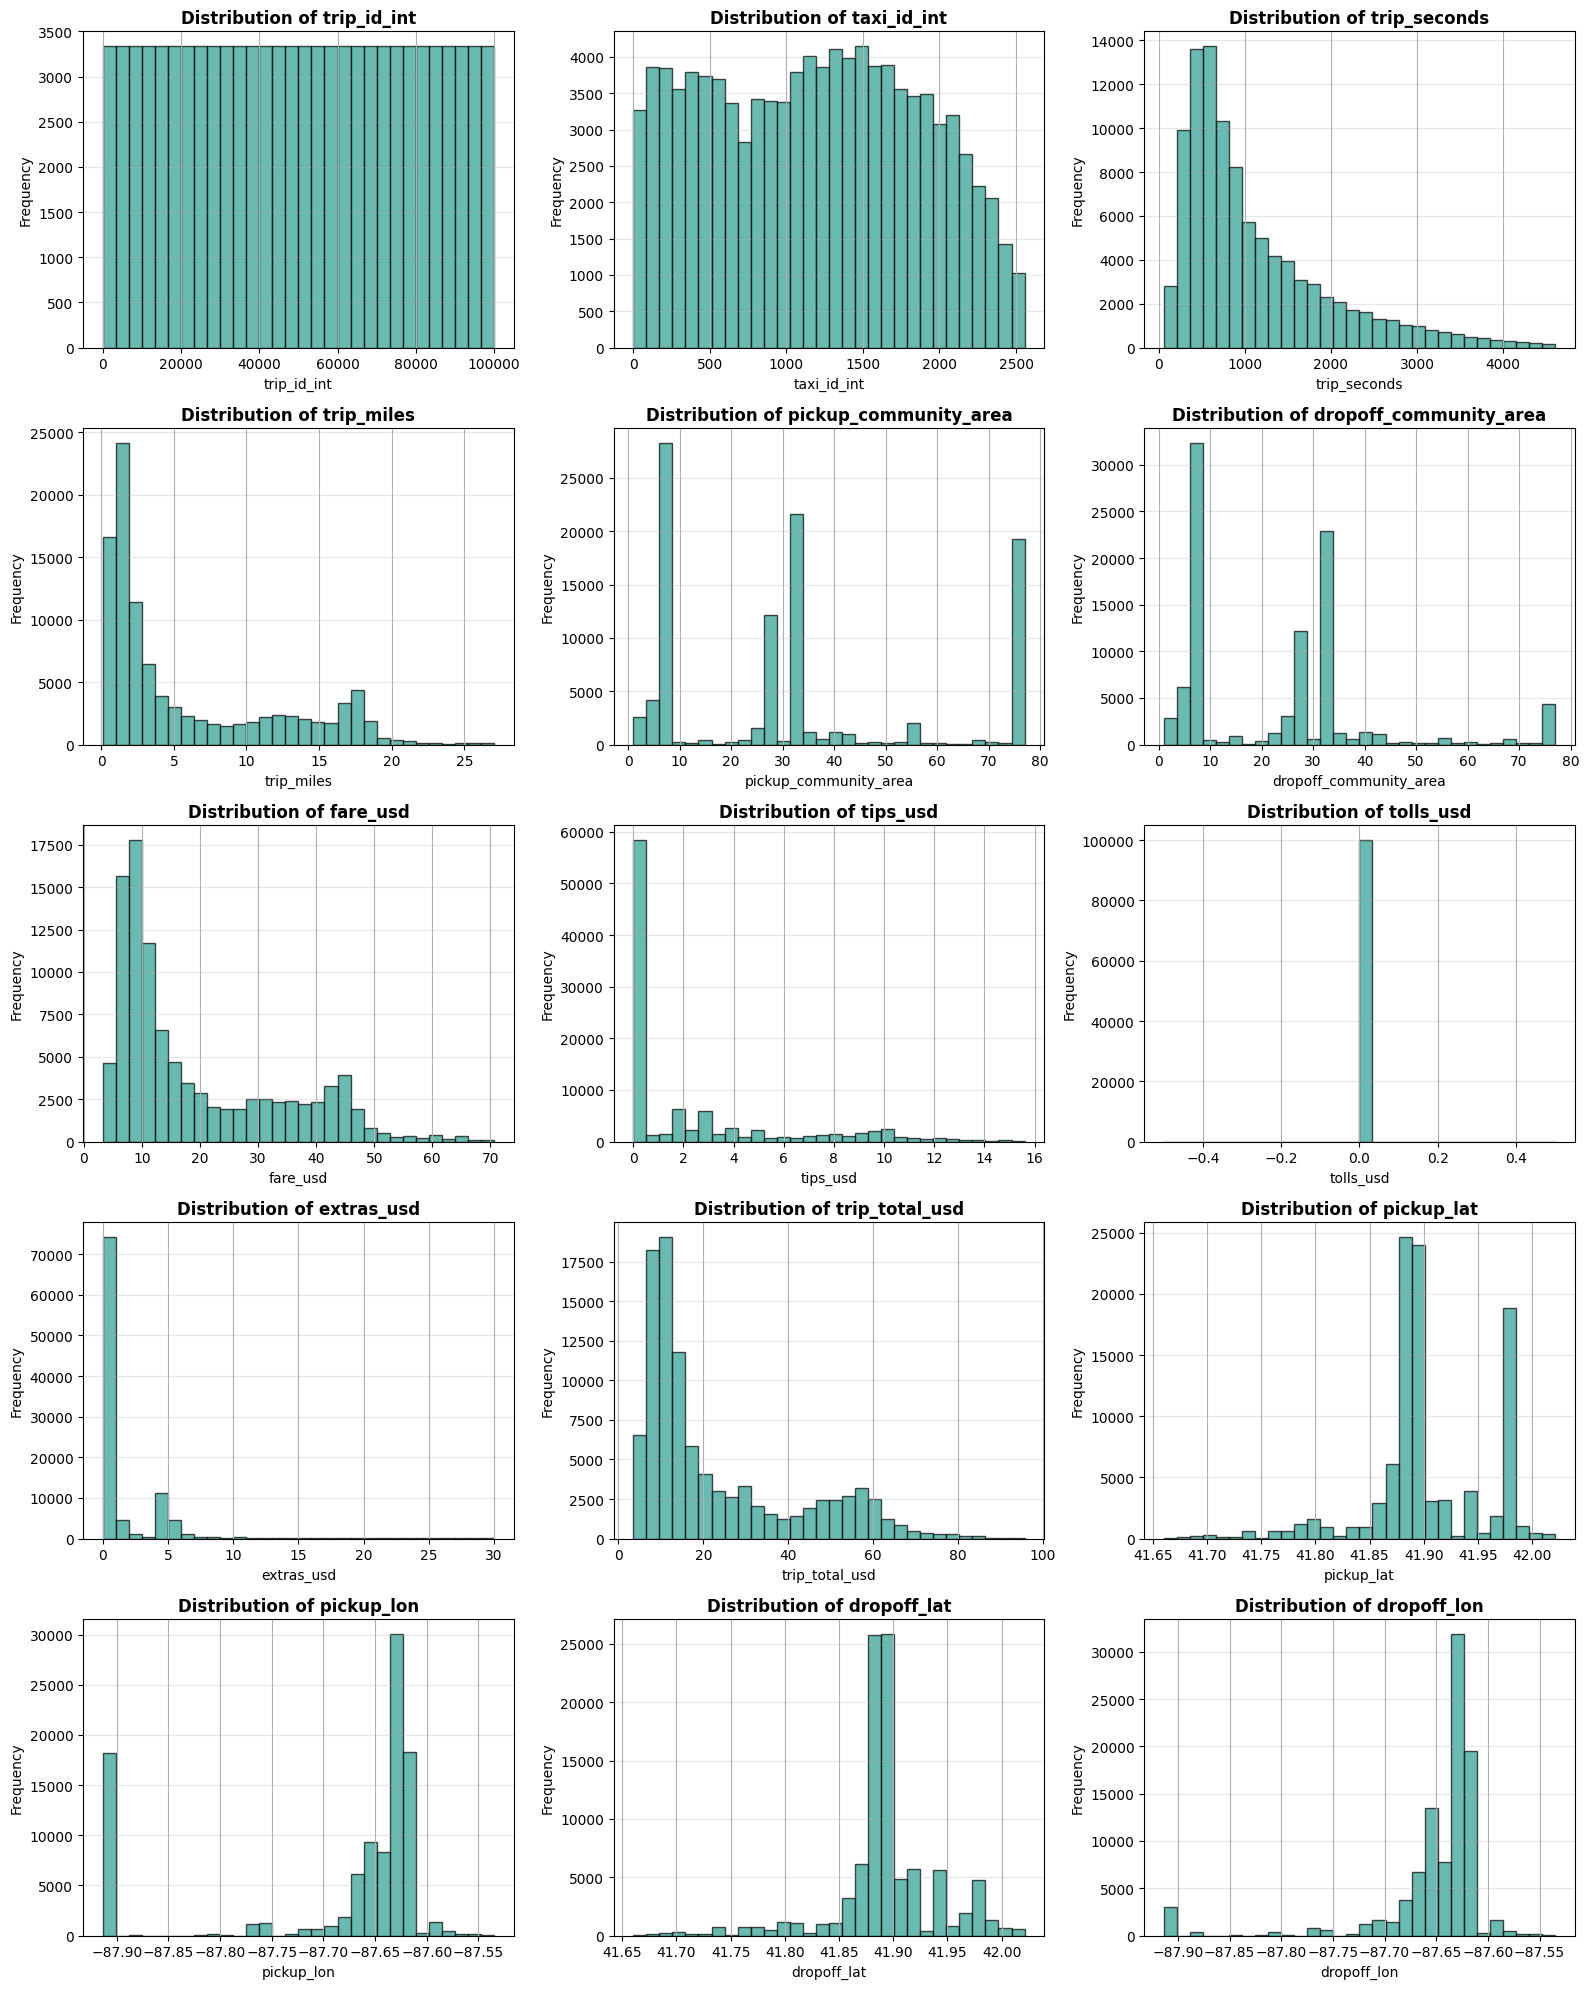

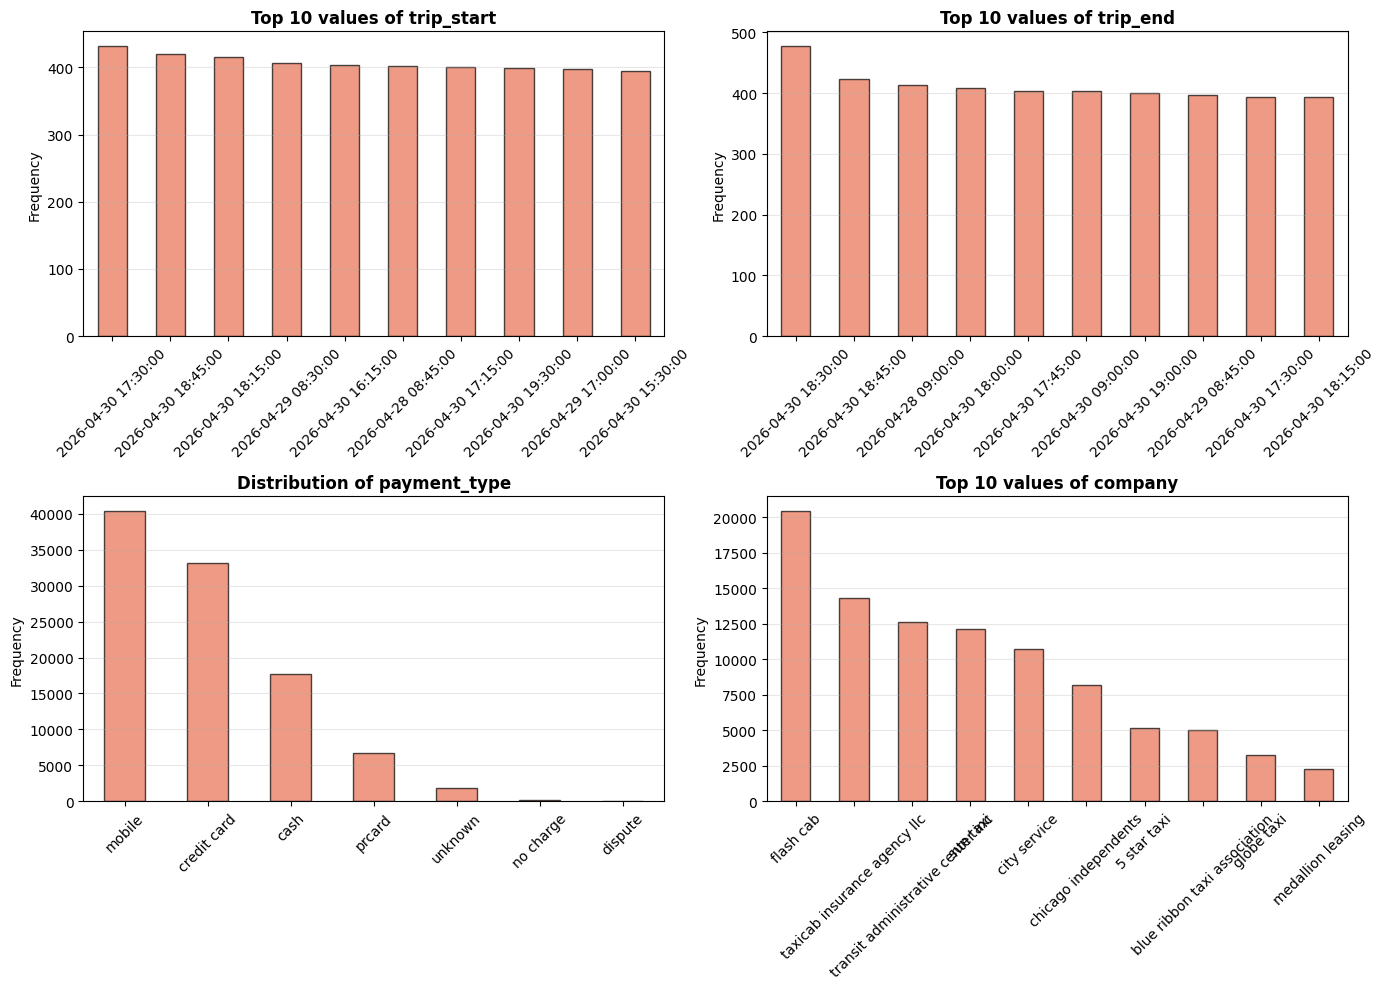

In [7]:
import matplotlib.pyplot as plt
import numpy as np

# Separate numeric and categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

# Create a figure with subplots for numeric columns
if numeric_cols:
    n_cols = 3
    n_rows = (len(numeric_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if len(numeric_cols) > 1 else [axes]
    
    for idx, col in enumerate(numeric_cols):
        ax = axes[idx]
        df[col].hist(bins=30, ax=ax, edgecolor='black', alpha=0.7, color='#2a9d8f')
        ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        ax.set_xlabel(col)
        ax.set_ylabel('Frequency')
        ax.grid(axis='y', alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(numeric_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()

# Create a figure with subplots for categorical columns
if categorical_cols:
    n_cols = 2
    n_rows = (len(categorical_cols) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 5 * n_rows))
    axes = axes.flatten() if len(categorical_cols) > 1 else [axes]
    
    for idx, col in enumerate(categorical_cols):
        ax = axes[idx]
        value_counts = df[col].value_counts()
        # Limit to top 10 categories if there are too many
        if len(value_counts) > 10:
            value_counts = value_counts.head(10)
            ax.set_title(f'Top 10 values of {col}', fontsize=12, fontweight='bold')
        else:
            ax.set_title(f'Distribution of {col}', fontsize=12, fontweight='bold')
        value_counts.plot(kind='bar', ax=ax, color='#e76f51', edgecolor='black', alpha=0.7)
        ax.set_ylabel('Frequency')
        ax.set_xlabel('')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
    
    # Hide unused subplots
    for idx in range(len(categorical_cols), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    plt.show()